# Reuso do pipeline em outro cenário — Segmentação de usuários de streaming

Este notebook não toca em `clustering_pipeline.py`. A única coisa que muda
do notebook do Mall Customers é **quais colunas** entram em
`numeric_features` / `categorical_features` / `id_columns` — prova de que
o pipeline é genérico e não foi construído em torno do dataset do shopping.

**Cenário:** uma plataforma de streaming quer segmentar usuários por
engajamento (horas assistidas/mês, dias ativos nos últimos 30, receita
mensal) e plano contratado, para decidir em quem investir retenção.

Dados sintéticos gerados abaixo só para demonstração — em uso real, viria
de uma tabela de billing/analytics.

In [1]:
import numpy as np
import pandas as pd

from clustering_pipeline import ClusterPipeline, check_data_quality

rng = np.random.default_rng(42)
n = 300

# três perfis latentes plausíveis, para os dados sintéticos não ficarem
# uniformemente aleatórios (senão nenhum cluster real existiria pra achar)
profile = rng.choice(["power_user", "casual", "churn_risk"], size=n, p=[0.25, 0.45, 0.30])

hours = np.where(
    profile == "power_user", rng.normal(45, 8, n),
    np.where(profile == "casual", rng.normal(15, 5, n), rng.normal(3, 2, n)),
).clip(0, None)

days_active = np.where(
    profile == "power_user", rng.normal(26, 3, n),
    np.where(profile == "casual", rng.normal(14, 4, n), rng.normal(3, 2, n)),
).clip(0, 30)

revenue = np.where(
    profile == "power_user", rng.normal(45, 6, n),
    np.where(profile == "casual", rng.normal(25, 5, n), rng.normal(12, 3, n)),
).clip(0, None)

account_age = rng.integers(1, 48, n)
plan = rng.choice(["Basic", "Standard", "Premium"], size=n, p=[0.3, 0.4, 0.3])

streaming_df = pd.DataFrame({
    "UserID": np.arange(1, n + 1),
    "Plan": plan,
    "MonthlyHoursWatched": hours.round(1),
    "DaysActiveLast30": days_active.round(0).astype(int),
    "MonthlyRevenue": revenue.round(2),
    "AccountAgeMonths": account_age,
})
streaming_df.head()

,UserID,Plan,MonthlyHoursWatched,DaysActiveLast30,MonthlyRevenue,AccountAgeMonths
0,1,Basic,0.0,4,15.86,24
1,2,Standard,23.1,15,24.78,13
2,3,Premium,1.3,0,8.16,11
3,4,Premium,16.2,14,28.53,29
4,5,Standard,56.8,25,45.79,38


## 1. Mesma checagem de qualidade, mesma função, dataset diferente

In [2]:
check_data_quality(streaming_df, id_columns=["UserID"])

Linhas: 300 | Colunas: 6
Linhas duplicadas: 0
Nulos por coluna:
  (nenhum)

Tipos de dado:
UserID                   int64
Plan                       str
MonthlyHoursWatched    float64
DaysActiveLast30         int64
MonthlyRevenue         float64
AccountAgeMonths         int64
dtype: object


,dtype,n_nulls,pct_nulls
UserID,int64,0,0.0
Plan,str,0,0.0
MonthlyHoursWatched,float64,0,0.0
DaysActiveLast30,int64,0,0.0
MonthlyRevenue,float64,0,0.0
AccountAgeMonths,int64,0,0.0


## 2. Mesmo `ClusterPipeline`, só trocando os parâmetros

Antes era `numeric_features=["Annual Income (k$)", "Spending Score (1-100)"]`.
Agora é engajamento de streaming — zero alteração de código no módulo.

In [3]:
pipe = ClusterPipeline(
    numeric_features=["MonthlyHoursWatched", "DaysActiveLast30", "MonthlyRevenue"],
    categorical_features=["Plan"],
    id_columns=["UserID"],
    random_state=42,
)
search = pipe.search_k(streaming_df, k_range=range(2, 8))
search

,k,inertia,silhouette
0,2,244.117884,0.648873
1,3,95.902195,0.636005
2,4,80.203783,0.513019
3,5,67.543387,0.408889
4,6,60.951925,0.408990
5,7,55.625485,0.387357


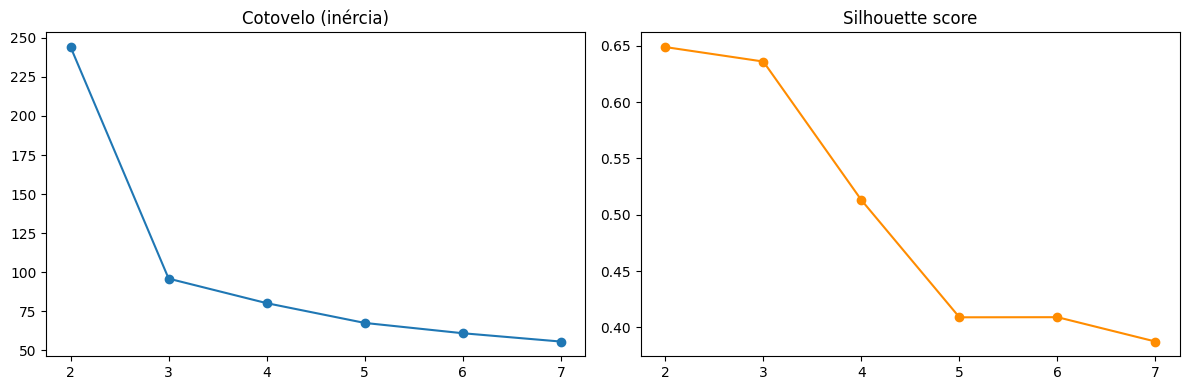

k recomendado por silhouette: 2 (silhouette=0.649)


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(search["k"], search["inertia"], marker="o")
axes[0].set_title("Cotovelo (inércia)")
axes[1].plot(search["k"], search["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()

k = pipe.recommend_k(method="silhouette")
print(f"k recomendado por silhouette: {k} (silhouette={search['silhouette'].max():.3f})")

In [5]:
labeled = pipe.fit_predict(streaming_df, n_clusters=k, cluster_col="Engagement Cluster")
pipe.profile(labeled, cluster_col="Engagement Cluster")

,MonthlyHoursWatched,DaysActiveLast30,MonthlyRevenue,n_customers,pct_of_total
Engagement Cluster,,,,,
0,10.52,9.14,19.88,215,71.7
1,45.44,26.13,45.64,85,28.3


In [6]:
pipe.categorical_profile(labeled, "Plan", cluster_col="Engagement Cluster")

Plan,Basic,Premium,Standard
Engagement Cluster,,,
0,0.256,0.298,0.447
1,0.365,0.235,0.400


## 3. Leitura de negócio

Os nomes dos segmentos mudam (aqui seria algo como "Power user", "Uso
casual", "Risco de churn"), mas o **método é idêntico** ao usado no
Mall Customers: mesma checagem de qualidade, mesma busca de k por
silhouette, mesmo `random_state` fixo, mesmo formato de perfil.

Isso é o que "fácil de aplicar em outro cenário" significa na prática:
trocar 3 listas de nomes de coluna, não reescrever a lógica de clustering.